In [3]:
import os
import pandas as pd

In [4]:
def export_daily_close_onecol(
    csv_path: str,
    out_txt_path: str,
    ticker: str,
    start_date: str | None = None,
    end_date: str | None = None,
    tz: str = "America/New_York",
):
    usecols_try = ["timestamp", "close", "ticker"]

    try:
        it = pd.read_csv(csv_path, usecols=usecols_try, chunksize=2_000_000, dtype={"ticker": "string"})
        timestamp_col = "timestamp"
    except ValueError:
        usecols_try = ["Unnamed: 0", "close", "ticker"]
        it = pd.read_csv(csv_path, usecols=usecols_try, chunksize=2_000_000, dtype={"ticker": "string"})
        timestamp_col = "Unnamed: 0"

    start = pd.Timestamp(start_date, tz=tz) if start_date else None
    end = pd.Timestamp(end_date, tz=tz) if end_date else None

    daily_parts = []

    for chunk in it:
        ts_utc = pd.to_datetime(chunk[timestamp_col], utc=True, errors="coerce")
        ts = ts_utc.dt.tz_convert(tz)

        mask = (chunk["ticker"] == ticker)
        if start is not None:
            mask &= (ts >= start)
        if end is not None:
            mask &= (ts <= end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))

        if mask.any():
            daily_parts.append(pd.DataFrame({"ts": ts[mask].values, "close": chunk.loc[mask, "close"].values}))

    if not daily_parts:
        open(out_txt_path, "w").close()
        return pd.Series(dtype="float64")

    df = pd.concat(daily_parts, ignore_index=True).sort_values("ts")
    daily_close = df.groupby(df["ts"].dt.date)["close"].last()

    daily_close.to_csv(out_txt_path, index=False, header=False, float_format="%.6f")
    return daily_close

In [5]:
csv_path = "SP500.min.2023Jan.bars.csv"
out_path = "VISA_close.txt"

print("CSV exists?", os.path.exists(csv_path))

daily = export_daily_close_onecol(
        csv_path=csv_path,
        out_txt_path=out_path,
        ticker="V",
        start_date="2023-01-01",
        end_date="2023-01-31",
    )

print("WROTE:", out_path, "exists?", os.path.exists(out_path))
print("N daily points:", len(daily))
print(daily.head())


CSV exists? True
WROTE: VISA_close.txt exists? True
N daily points: 23
ts
2023-01-03    207.36
2023-01-04    212.10
2023-01-05    211.80
2023-01-06    217.70
2023-01-07    217.70
Name: close, dtype: float64


In [6]:
import os
print(os.getcwd())
print(os.listdir())

/Users/solomonmiragias/Desktop/Software Final Project
['advsoft_project_spring2026 (1).pdf', 'SP500.min.2023Jan.bars.csv', '.DS_Store', 'Appendix1 (1).py', 'max_profit_algorithm (1).pdf', 'Appendix2 (1).py', 'Visa_project.ipynb', '.ipynb_checkpoints', 'VISA_close.txt']


In [7]:
mean_price = daily.mean()

std_price = daily.std()

print("Mean:", round(mean_price, 2))

print("Std Dev:", round(std_price, 2))

Mean: 222.11
Std Dev: 6.12


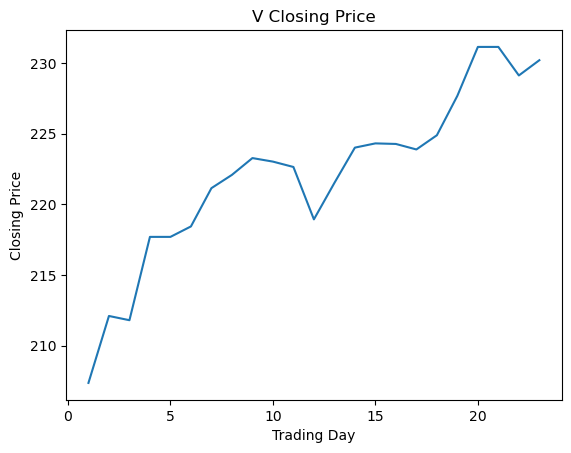

In [8]:
import matplotlib.pyplot as plt

# x-axis must be integers 1 to N
x = range(1, len(daily) + 1)

# create line graph
plt.plot(x, daily.values)

# required title and labels
plt.title("V Closing Price")
plt.xlabel("Trading Day")
plt.ylabel("Closing Price")

# save graph as image for LaTeX report
plt.savefig("V_closing_price_graph.png", dpi=300, bbox_inches="tight")

# show graph
plt.show()

In [10]:
import pandas as pd

prices = pd.read_csv("VISA_close.txt", header=None)[0].values

min_price = prices[0]
max_profit = 0

buy_day = 0
sell_day = 0
temp_buy_day = 0

for i in range(1, len(prices)):
    profit = prices[i] - min_price

    if profit > max_profit:
        max_profit = profit
        buy_day = temp_buy_day
        sell_day = i

    if prices[i] < min_price:
        min_price = prices[i]
        temp_buy_day = i

print("Max Profit:", round(max_profit, 2))
print("Buy Day:", buy_day + 1)
print("Sell Day:", sell_day + 1)

Max Profit: 23.79
Buy Day: 1
Sell Day: 20
